In [1]:
!pip install -q transformers accelerate bitsandbytes


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os
from dotenv import load_dotenv

# Load variables from .env
load_dotenv()

# Access the token
hf_token = os.getenv("HF_TOKEN")
model_id = "meta-llama/Meta-Llama-3.1-8B"

c:\Users\User\Documents\TECHNION\semester 7\חיפוש מחקר\soudry\itay\k-v clustering\k_clustering\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# load model with original float16 weights
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16, 
    device_map="cpu", # initial loading into system RAM to prevent crashing
    token=hf_token
)

Loading checkpoint shards: 100%|██████████| 4/4 [00:53<00:00, 13.48s/it]


In [5]:
w_k_matrix = model.model.layers[0].self_attn.k_proj.weight.data

In [6]:
w_k_np = w_k_matrix.detach().cpu().numpy()

print(f"Shape: {w_k_np.shape}")
print(f"First few values: \n{w_k_np[:3, :3]}")

Shape: (1024, 4096)
First few values: 
[[-0.105   -0.1504   0.0825 ]
 [-0.05737 -0.0835   0.01721]
 [-0.01855 -0.052    0.0442 ]]


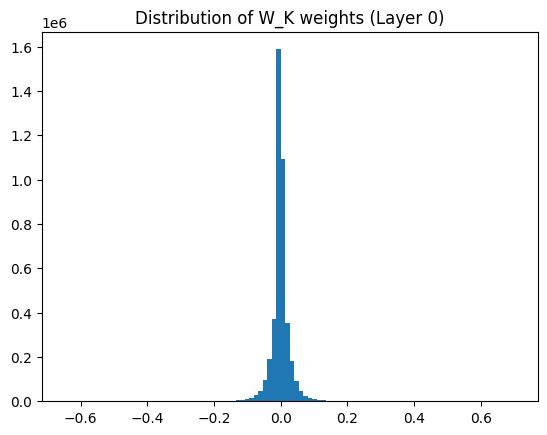

Mean: -9.298324584960938e-06
Std: 0.027069091796875


In [7]:
import matplotlib.pyplot as plt

plt.hist(w_k_np.flatten(), bins=100)
plt.title("Distribution of W_K weights (Layer 0)")
plt.show()

print(f"Mean: {w_k_np.mean()}")
print(f"Std: {w_k_np.std()}")

Head 0 squared Frobenius distance from average: 341.5035
Head 1 squared Frobenius distance from average: 338.1794
Head 2 squared Frobenius distance from average: 465.1602
Head 3 squared Frobenius distance from average: 266.5489
Head 4 squared Frobenius distance from average: 205.6826
Head 5 squared Frobenius distance from average: 245.8513
Head 6 squared Frobenius distance from average: 642.3999
Head 7 squared Frobenius distance from average: 180.6297


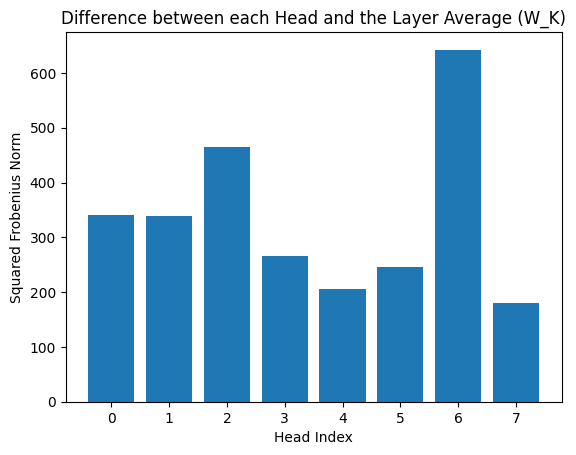

In [ ]:
# distance from avg
import torch

wk_full = model.model.layers[0].self_attn.k_proj.weight.data.to(torch.float32)

# split to heads
num_heads = 8
head_dim = 128
hidden_size = 4096

heads = wk_full.view((num_heads, head_dim, hidden_size))

# calculate avg w_K
wk_head_avg = torch.mean(heads, dim=0)

# calculate distance from avg
head_distances = []
for i in range(num_heads):
    wk_i = heads[i]
    diff = wk_i - wk_head_avg
    dist = torch.norm(diff, p='fro')**2
    head_distances.append(dist.item())
    print(f"Head {i} squared Frobenius distance from average: {dist.item():.4f}")

# visualize
import matplotlib.pyplot as plt
plt.bar(range(num_heads), head_distances)
plt.xlabel("Head Index")
plt.ylabel("Squared Frobenius Norm")
plt.title("Difference between each Head and the Layer Average (W_K)")
plt.show()

Head 0 squared Frobenius distance from w_k1: 0.0000
Head 1 squared Frobenius distance from w_k1: 758.6052
Head 2 squared Frobenius distance from w_k1: 942.9396
Head 3 squared Frobenius distance from w_k1: 678.9514
Head 4 squared Frobenius distance from w_k1: 601.7218
Head 5 squared Frobenius distance from w_k1: 675.0220
Head 6 squared Frobenius distance from w_k1: 1192.5032
Head 7 squared Frobenius distance from w_k1: 568.3611


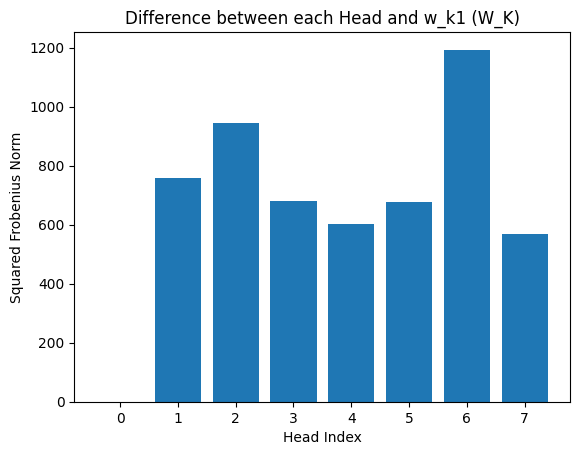

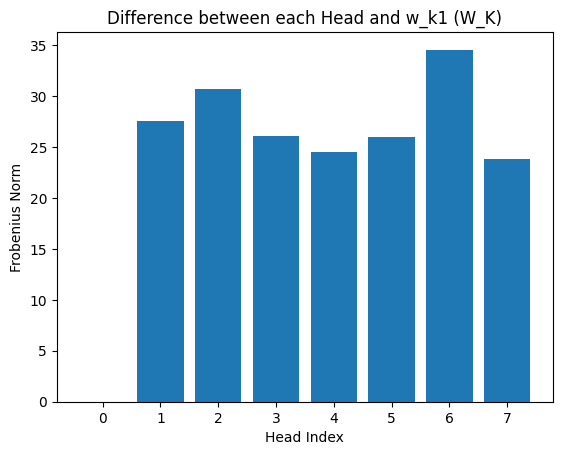

In [13]:
# distance from W_k1
import torch

wk_full = model.model.layers[0].self_attn.k_proj.weight.data.to(torch.float32)

# split to heads
num_heads = 8
head_dim = 128
hidden_size = 4096

heads = wk_full.view((num_heads, head_dim, hidden_size))

# calculate w_k1
w_k1 = heads[0]

# calculate distance from w_k1
head_distances = []
for i in range(num_heads):
    wk_i = heads[i]
    diff = wk_i - w_k1
    dist = torch.norm(diff, p='fro')**2
    head_distances.append(dist.item())
    print(f"Head {i} squared Frobenius distance from w_k1: {dist.item():.4f}")

# visualize
import matplotlib.pyplot as plt
plt.bar(range(num_heads), head_distances)
plt.xlabel("Head Index")
plt.ylabel("Squared Frobenius Norm")
plt.title("Difference between each Head and w_k1 (W_K)")
plt.show()

plt.bar(range(num_heads), [head_distances[i]**0.5 for i in range(num_heads)])
plt.xlabel("Head Index")
plt.ylabel("Frobenius Norm")
plt.title("Difference between each Head and w_k1 (W_K)")
plt.show()

Processing 32 layers...


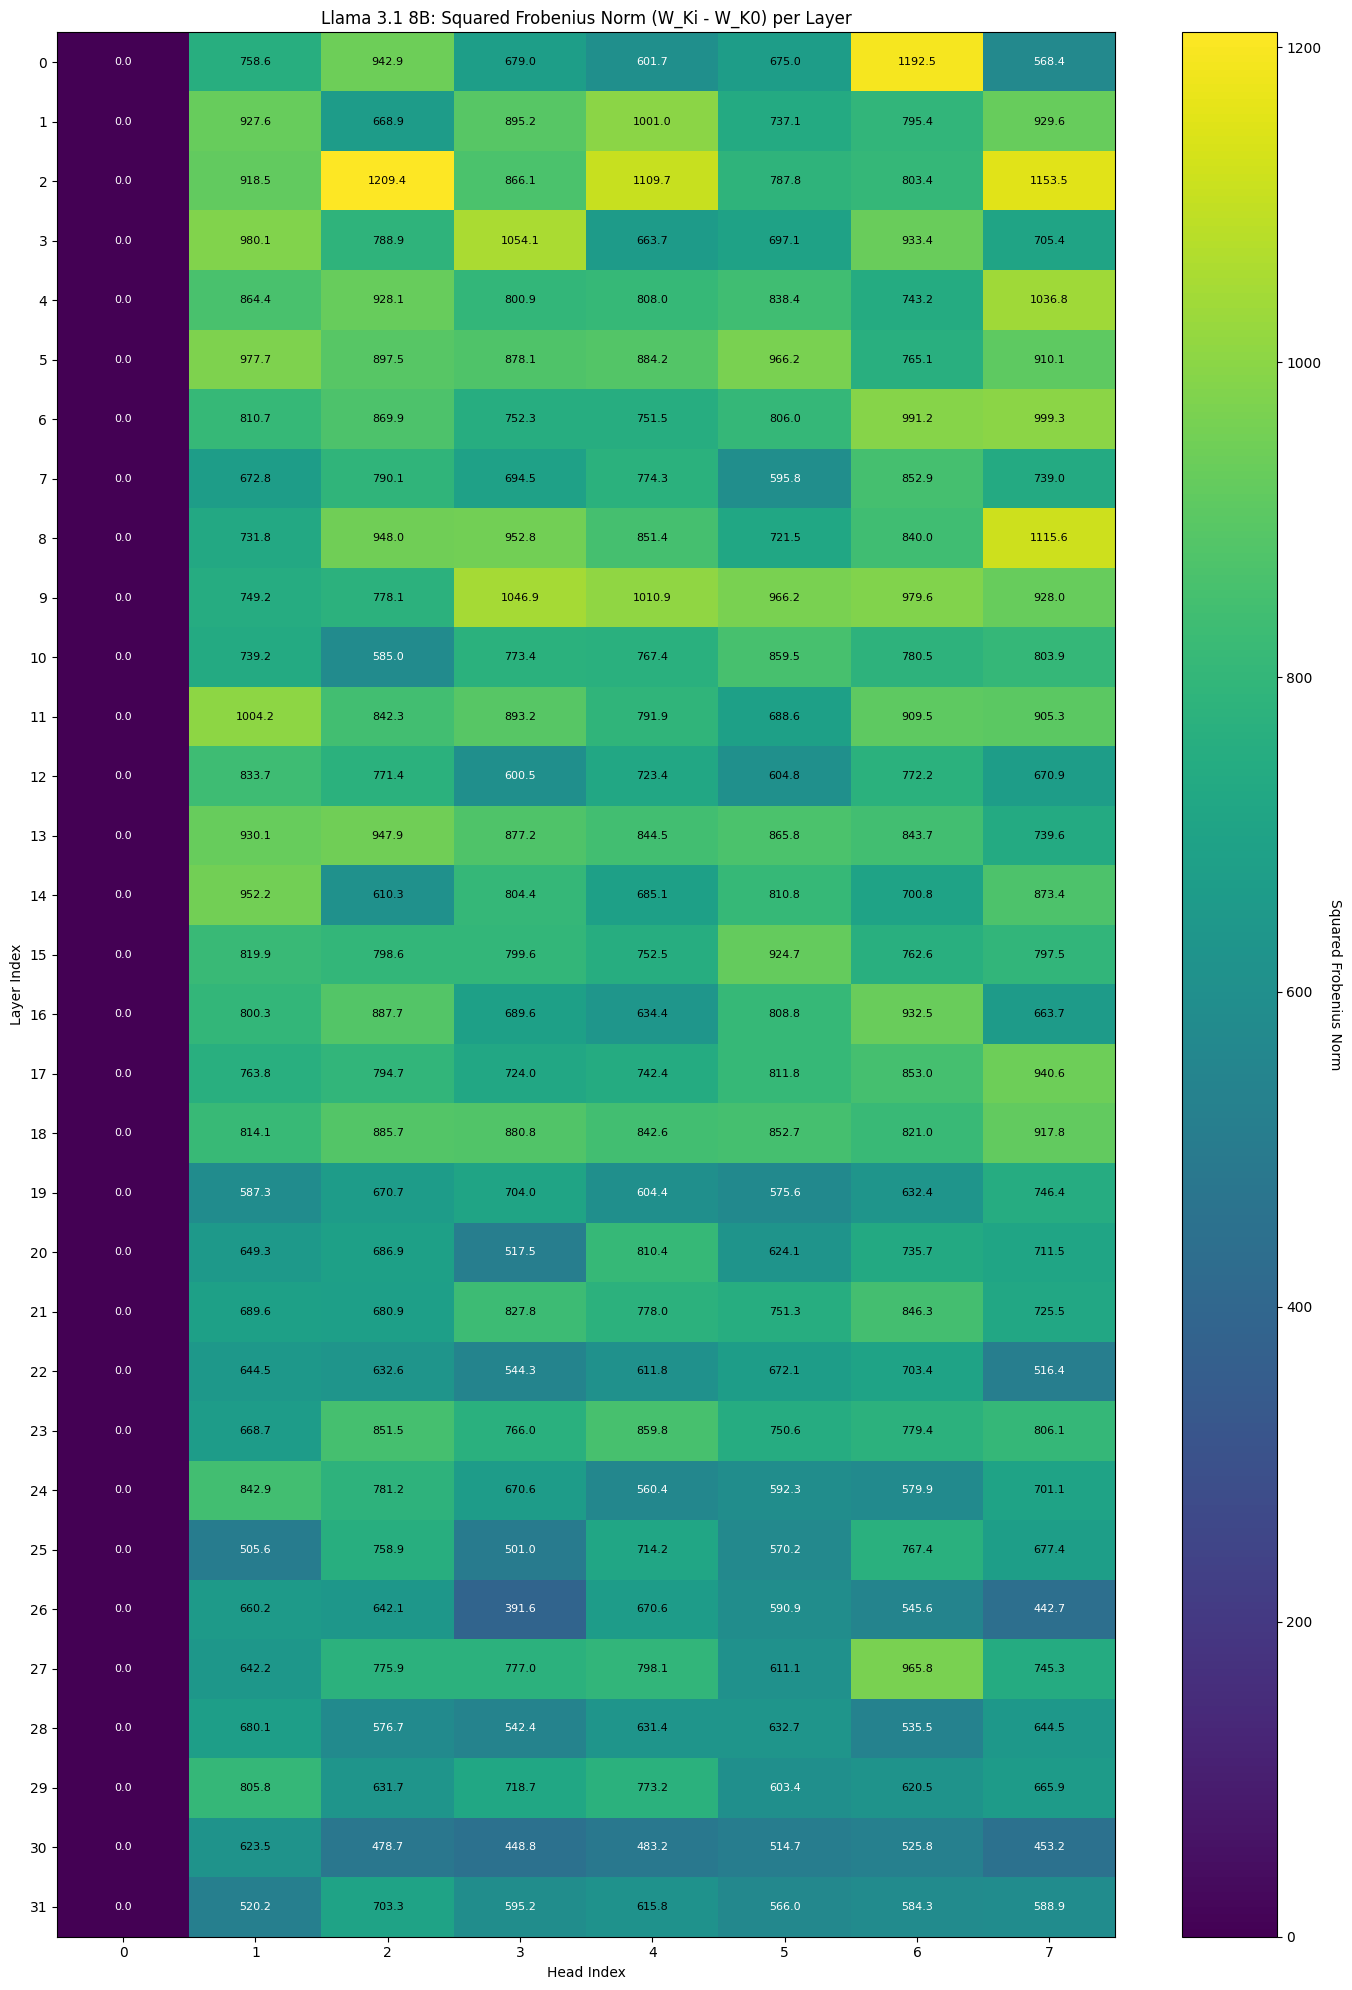

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup dimensions
num_layers = len(model.model.layers)
num_heads = 8
head_dim = 128
hidden_size = 4096

# Initialize matrix to store results
all_distances = np.zeros((num_layers, num_heads))

print(f"Processing {num_layers} layers...")

# 2. Compute Distances
for layer_idx in range(num_layers):
    # Extract weights and cast to float32 for precision
    wk_full = model.model.layers[layer_idx].self_attn.k_proj.weight.data.to(torch.float32)
    
    # Reshape into [heads, head_dim, hidden_size]
    heads = wk_full.reshape(num_heads, head_dim, hidden_size)
    
    # Set reference (Head 0 of current layer)
    w_k1 = heads[0]
    
    for head_idx in range(num_heads):
        wk_i = heads[head_idx]
        # Calculate Squared Frobenius Norm
        diff = wk_i - w_k1
        dist = torch.norm(diff, p='fro')**2
        all_distances[layer_idx, head_idx] = dist.item()

# 3. Visualization with Text Annotations
plt.figure(figsize=(14, 20)) # Increased height for readability
im = plt.imshow(all_distances, aspect='auto', cmap='viridis')

# Add Colorbar
cbar = plt.colorbar(im)
cbar.set_label('Squared Frobenius Norm', rotation=270, labelpad=15)

# Add exact numbers inside each square
for i in range(num_layers):
    for j in range(num_heads):
        # Formatting to 1 decimal place to avoid clutter
        val = all_distances[i, j]
        color = "white" if val < np.max(all_distances)/2 else "black"
        plt.text(j, i, f'{val:.1f}', ha="center", va="center", color=color, fontsize=8)

# Labels and Title
plt.xlabel("Head Index")
plt.ylabel("Layer Index")
plt.title("Llama 3.1 8B: Squared Frobenius Norm (W_Ki - W_K0) per Layer")

plt.xticks(range(num_heads))
plt.yticks(range(num_layers))

plt.tight_layout()
plt.show()

In [16]:
# Calculate the squared norm of the reference head (Head 0)
# This represents the "energy" or "magnitude" of the matrix
w_k1_norm_sq = torch.norm(w_k1, p='fro')**2

# Calculate Relative Distance
relative_dist = dist / w_k1_norm_sq
print(f"Relative Distance: {relative_dist.item():.4%}")

Relative Distance: 196.7577%


In [10]:
#calculate RELATIVE DISTANCE
import torch
import matplotlib.pyplot as plt
import numpy as np

def get_W_K(heads, w_k_name):
    num_heads, head_dim, hidden_size = heads.shape # [8, 128, 4096]

    if w_k_name == "w_k1":
        return heads[0]

    elif w_k_name == "avg W_Ki":
        return torch.mean(heads, dim=0)

    elif w_k_name == "svd":
        wk_full = heads.reshape(-1, hidden_size) 
        U, S, Vh = torch.linalg.svd(wk_full, full_matrices=False)
        
        # We take the top 'head_dim' (128) singular values and vectors.
        # This is the "best possible" matrix of size 128x4096 
        # that represents the shared information of the full 1024x4096 matrix.
        k = head_dim 
        S_k = torch.diag(S[:k])
        Vh_k = Vh[:k, :]

        # We don't need U here because we want a representative 'Head' 
        # that lives in the same row-space (V) as the original weights.
        # The reference is constructed from the top 128 principal directions.
        svd_reference = S_k @ Vh_k # Resulting shape: [128, 4096]
        
        return svd_reference

    elif w_k_name == "svd (avg)":
        avg_head = torch.mean(heads, dim=0)
        # We use full_matrices=False for efficiency
        U, S, Vh = torch.linalg.svd(avg_head, full_matrices=False)
        
        # 3. Reconstruct using only the first singular value (Rank-1 Approximation)
        # This represents the "Principal Component" of the W_K projection
        # Formula: u_1 * s_1 * v_1^T
        s_1 = S[0]
        u_1 = U[:, 0:1]
        vh_1 = Vh[0:1, :]
        
        svd_reference = u_1 @ (s_1 * vh_1)
        return svd_reference

    elif w_k_name == "I":
        return torch.eye(head_dim, hidden_size)
    
    elif w_k_name == "0":
        return torch.zeros(head_dim, hidden_size)
    else:
        raise ValueError(f"Invalid W_K name: {w_k_name}")

def calculate_relative_dist(w_k_name="W_K"):
    # 1. Setup dimensions
    num_layers = len(model.model.layers)
    num_heads = 8
    head_dim = 128
    hidden_size = 4096

    # Initialize matrix for 8 heads + 1 column for the Mean
    # Shape: [32 layers, 9 columns]
    results_matrix = np.zeros((num_layers, num_heads + 1))

    print(f"Calculating relative distances for {num_layers} layers...")

    # 2. Compute Relative Distances
    for layer_idx in range(num_layers):
        # Get weights for the current layer
        wk_full = model.model.layers[layer_idx].self_attn.k_proj.weight.data.to(torch.float32)
        
        # Reshape to separate the heads
        heads = wk_full.reshape(num_heads, head_dim, hidden_size)
        
        # Define Reference W_K and its squared norm for normalization
        w_k = get_W_K(heads, w_k_name)
        norm_ref_sq = torch.norm(w_k, p='fro')**2
        
        current_layer_distances = []
        
        for head_idx in range(num_heads):
            wk_i = heads[head_idx]
            
            # Calculate Squared Frobenius distance: ||W_Ki - W_K||^2
            diff_sq = torch.norm(wk_i - w_k, p='fro')**2
            
            # Calculate Relative Distance as a percentage
            # Formula: (Distance / Reference Norm) * 100
            relative_dist = (diff_sq / norm_ref_sq).item() * 100
            
            results_matrix[layer_idx, head_idx] = relative_dist
            
            # We collect distances of heads 1-7 to calculate a meaningful average
            #if head_idx > 0:
            current_layer_distances.append(relative_dist)
                
        # Calculate the mean diversity of the layer (excluding Head 0 which is 0%)
        results_matrix[layer_idx, num_heads] = np.mean(current_layer_distances)

    # 3. Visualization

    import seaborn as sns
    import matplotlib.pyplot as plt

    # 1. Set a smaller figure size (width, height)
    plt.figure(figsize=(10, 12)) 

    # 2. Define labels for the axes
    head_labels = [f"H{i}" for i in range(num_heads)] + ["AVG"]

    # 3. Create the heatmap using Seaborn
    # annot=True adds the numbers automatically
    # fmt=".1f" formats to 1 decimal point
    # annot_kws sets the font size inside the squares
    ax = sns.heatmap(
        results_matrix, 
        annot=True, 
        fmt=".1f", 
        cmap='viridis', 
        xticklabels=head_labels,
        yticklabels=range(num_layers),
        annot_kws={"size": 7} 
    )

    # 4. Styling
    plt.title(f"Llama 3.1 8B: Relative W_K ({w_k_name}) Divergence (%)", fontsize=14)
    plt.xlabel("Head Index", fontsize=10)
    plt.ylabel("Layer Index", fontsize=10)

    # Optional: rotate y-axis labels for better fit
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

    """
    plt.figure(figsize=(16, 22))
    im = plt.imshow(results_matrix, aspect='auto', cmap='viridis')

    # Colorbar setup
    cbar = plt.colorbar(im)
    cbar.set_label('Relative Distance (%)', rotation=270, labelpad=20, fontsize=12)

    # Add text annotations (exact percentages) inside each square
    for i in range(num_layers):
        for j in range(num_heads + 1):
            val = results_matrix[i, j]
            # Adjust text color for readability based on background brightness
            text_color = "white" if val < np.max(results_matrix)/2 else "black"
            plt.text(j, i, f'{val:.1f}%', ha="center", va="center", color=text_color, fontsize=9)

    # Labels and Styling
    head_labels = [f"Head {i}" for i in range(num_heads)] + ["LAYER AVG"]
    plt.xticks(range(num_heads + 1), head_labels, fontweight='bold')
    plt.yticks(range(num_layers))

    plt.xlabel("Attention Head Index / Summary Metric", fontsize=12)
    plt.ylabel("Layer Index", fontsize=12)
    plt.title("Llama 3.1 8B: Relative Weight Divergence in W_K Matrices\n"
            "Value = (||W_Ki - W_K0||² / ||W_K0||²) * 100", fontsize=14, pad=20)

    plt.tight_layout()
    plt.show()"""

    print(f"Overall Average Relative Distance across all layers ({w_k_name}): {np.mean(results_matrix[:, num_heads]):.2f}%")

Calculating relative distances for 32 layers...


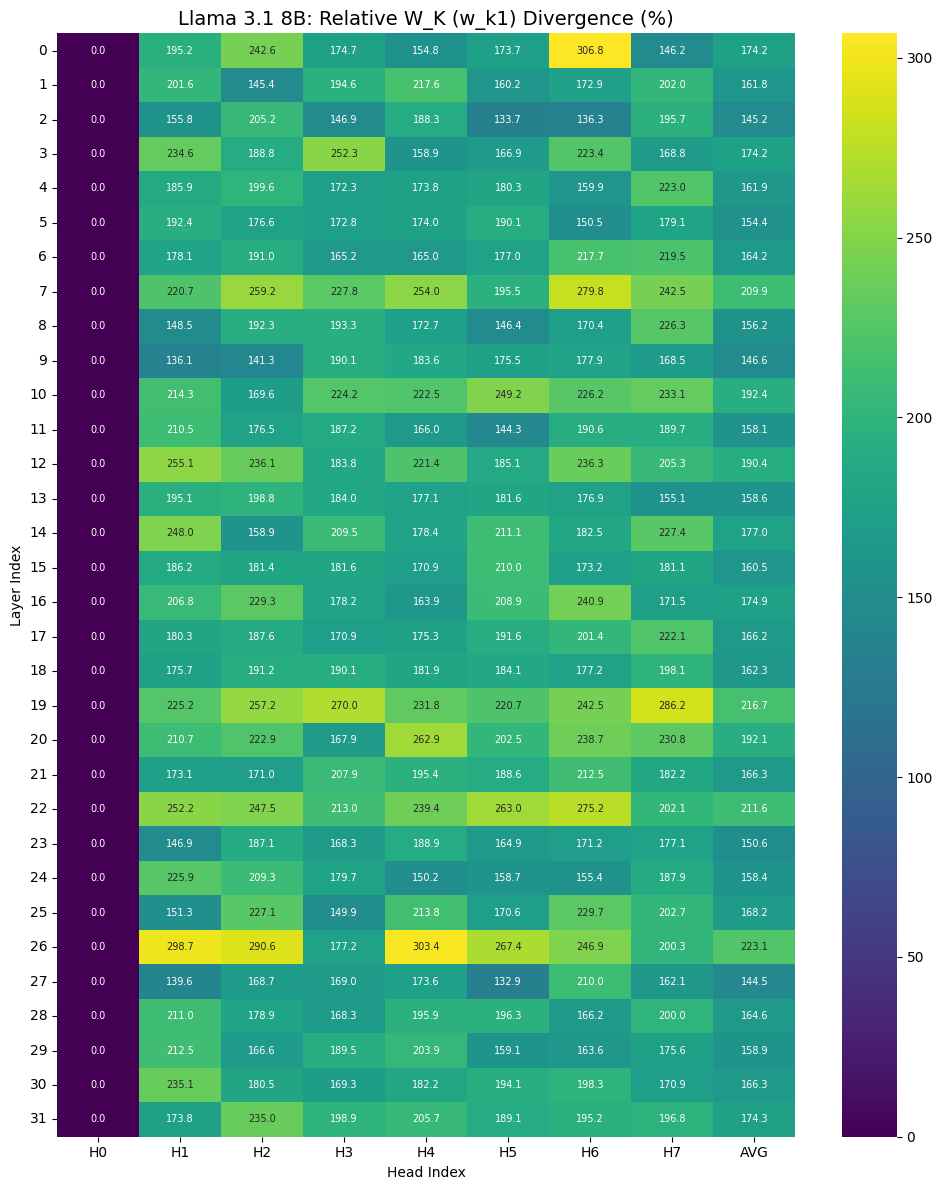

Overall Average Relative Distance across all layers (w_k1): 171.39%


In [38]:
calculate_relative_dist("w_k1")

Calculating relative distances for 32 layers...


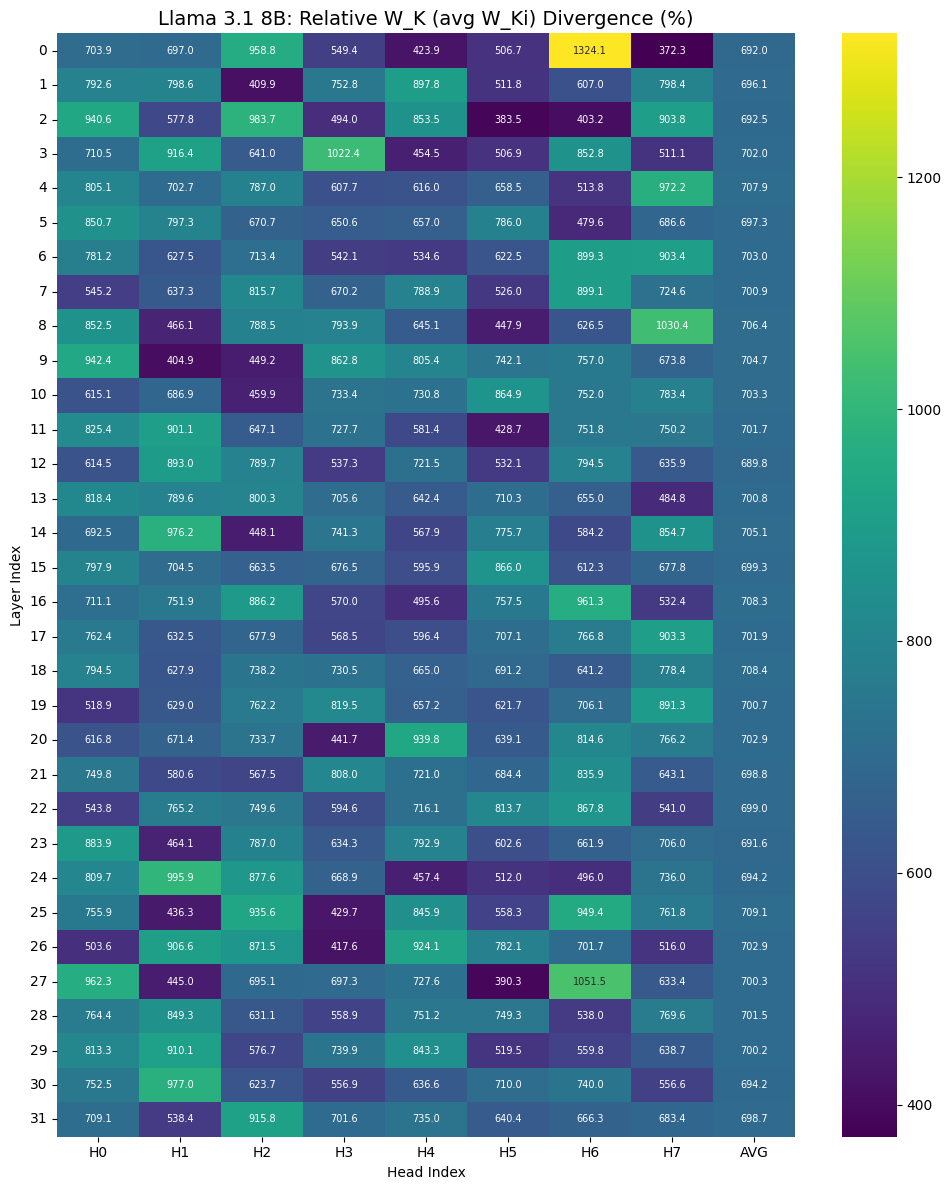

Overall Average Relative Distance across all layers (avg W_Ki): 700.47%


In [39]:
calculate_relative_dist("avg W_Ki")

Calculating relative distances for 32 layers...


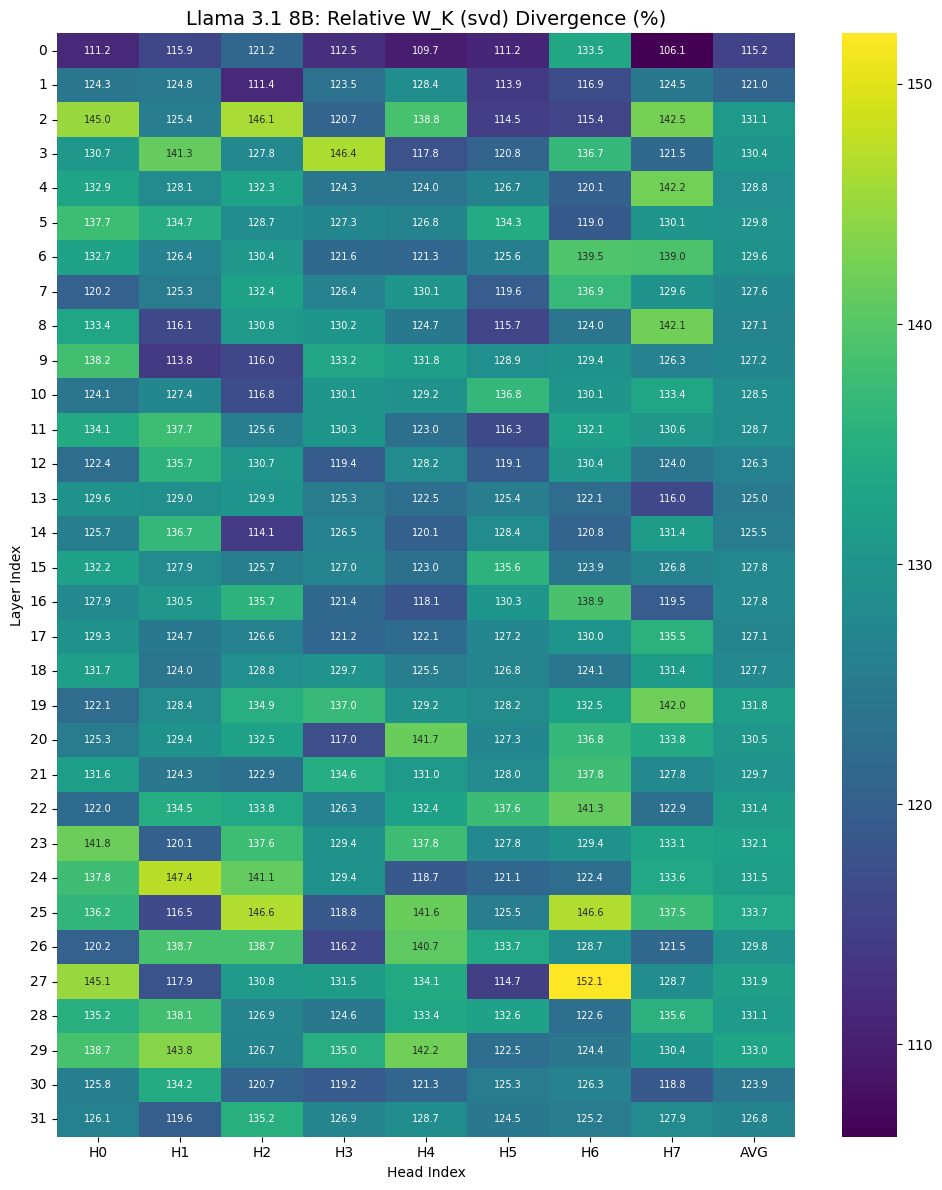

Overall Average Relative Distance across all layers (svd): 128.41%


In [48]:
calculate_relative_dist("svd")

Calculating relative distances for 32 layers...


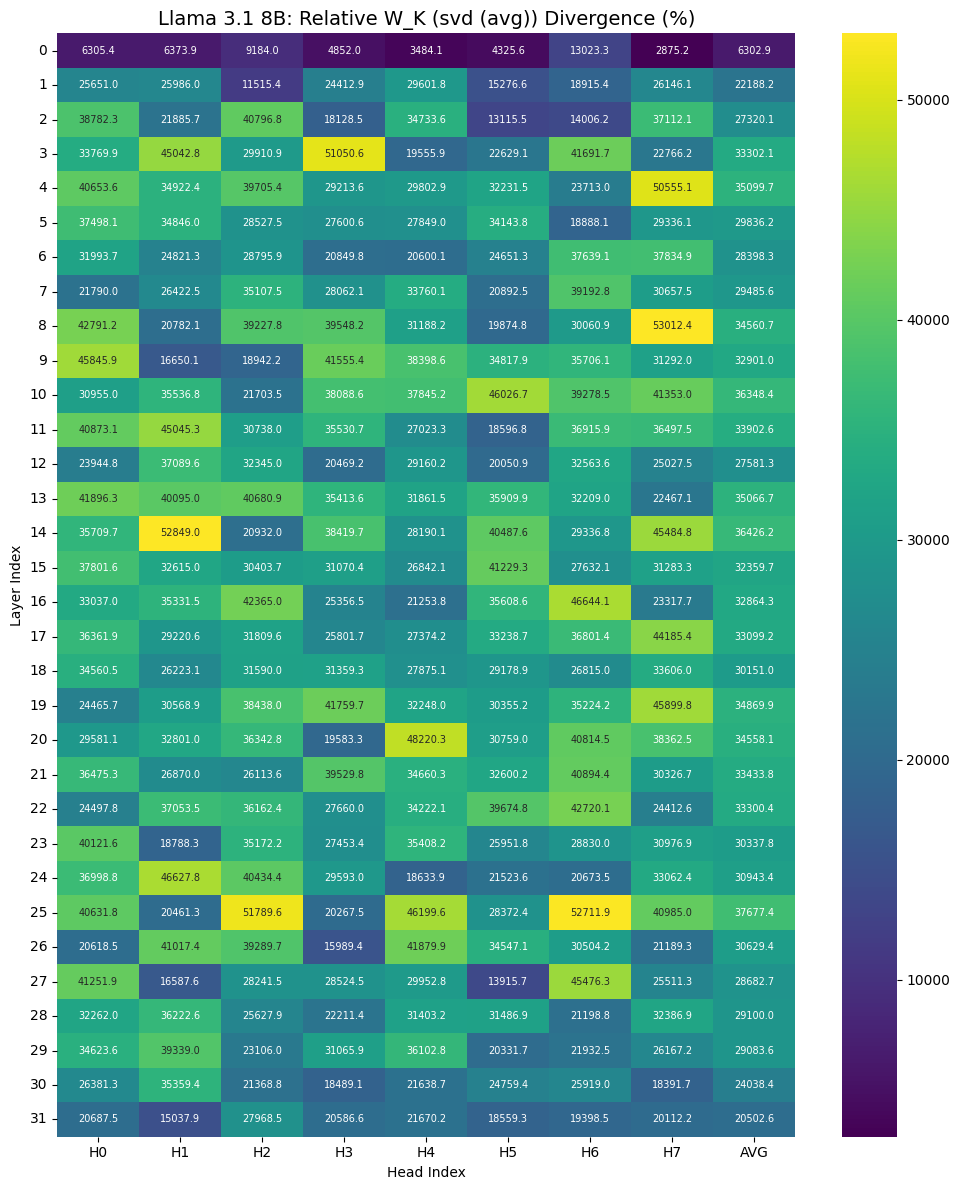

Overall Average Relative Distance across all layers (svd (avg)): 30448.49%


In [41]:
calculate_relative_dist("svd (avg)")

Calculating relative distances for 32 layers...


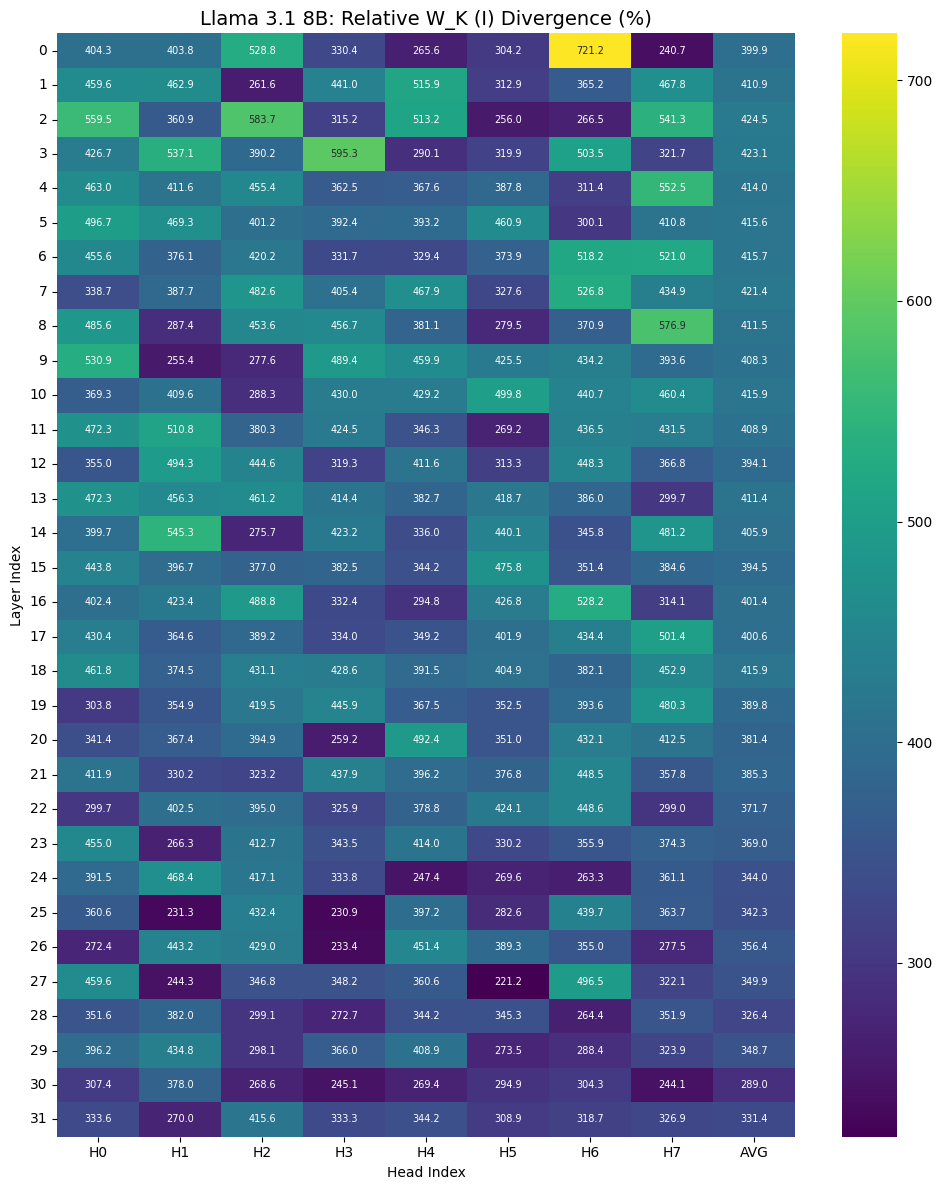

Overall Average Relative Distance across all layers (I): 386.84%


In [43]:
calculate_relative_dist("I")

In [20]:
wk1 = heads[0]
wk2 = heads[1]
print(torch.norm(wk1, p='fro')**2)
print(torch.norm(wk2, p='fro')**2)
print(torch.norm(wk1 - wk2, p='fro')**2)
print((torch.norm(wk1 - wk2, p='fro')**2) / (torch.norm(wk1, p='fro')**2))


tensor(299.2941)
tensor(217.1263)
tensor(520.2112)
tensor(1.7381)


## FIND OPTIMAL A

In [2]:
def get_optimal_procrustes_distance(W_ki, W_ref):
    """
    Finds the optimal A that minimizes ||W_ki @ A - W_ref||_F^2
    where A is an orthogonal matrix.
    Returns the relative distance after the best possible alignment.
    """
    # 1. Compute SVD of the product to find the optimal rotation/reflection
    # The product is (W_ki^T @ W_ref)
    M = torch.matmul(W_ki.T, W_ref)
    U, S, Vh = torch.linalg.svd(M, full_matrices=False)
    
    # 2. The optimal A is U @ Vh
    A_opt = torch.matmul(U, Vh)
    
    # 3. Calculate the new W_ki after alignment
    W_ki_aligned = torch.matmul(W_ki, A_opt)
    
    # 4. Compute the relative distance with the alignment
    dist_sq = torch.norm(W_ki_aligned - W_ref, p='fro')**2
    ref_norm_sq = torch.norm(W_ref, p='fro')**2
    
    relative_dist = (dist_sq / ref_norm_sq).item() * 100
    return relative_dist

In [8]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def get_optimal_procrustes_distance(W_ki, W_ref):
    # 1. Compute SVD of the product to find the optimal alignment
    # We want to find A that minimizes ||W_ki @ A - W_ref||_F
    M = torch.matmul(W_ki.T, W_ref)
    U, S, Vh = torch.linalg.svd(M, full_matrices=False)
    
    # 2. The optimal orthogonal matrix A is U @ Vh
    A_opt = torch.matmul(U, Vh)
    
    # 3. Apply alignment and calculate relative distance
    W_ki_aligned = torch.matmul(W_ki, A_opt)
    dist_sq = torch.norm(W_ki_aligned - W_ref, p='fro')**2
    ref_norm_sq = torch.norm(W_ref, p='fro')**2
    
    return (dist_sq / ref_norm_sq).item() * 100

def get_least_squares_distance(W_ki, W_ref):  #Second approach to test - least square pseudo inverse solution (gemini claims it doesn't fit here)
    # Solve for A: W_ki @ A = W_ref
    # A = torch.linalg.lstsq(W_ki, W_ref).solution
    # But more simply using the pseudo-inverse:
    #print(f"Shape of W_ki: {W_ki.shape}")
    #print(f"Shape of W_ref: {W_ref.shape}")
    W_ki_pinv = torch.linalg.pinv(W_ki)
    #print(f"Shape of W_ki_pinv: {W_ki_pinv.shape}")

    A_opt = torch.matmul(W_ki_pinv, W_ref)
    #print(f"Shape of A_opt: {A_opt.shape}")
    
    W_ki_transformed = torch.matmul(W_ki, A_opt)
    #print(f"Shape of W_ki_transformed: {W_ki_transformed.shape}")

    dist_sq = torch.norm(W_ki_transformed - W_ref, p='fro')**2
    ref_norm_sq = torch.norm(W_ref, p='fro')**2
    return (dist_sq / ref_norm_sq).item() * 100

def calculate_dist_with_optimal_A(w_k_name="svd", opt_mat_func=get_optimal_procrustes_distance, sanity_check=False):
    # Setup and Loop
    num_layers = len(model.model.layers)
    num_heads = 8
    results_matrix = np.zeros((num_layers, num_heads + 1))

    print("Calculating Optimized Procrustes Distances...")

    for layer_idx in range(num_layers):
        if sanity_check:
            n_heads = 8
            head_dim = 128
            model_dim = 4096

            mock_wk = torch.zeros((n_heads * head_dim, model_dim), dtype=torch.float32)
            
            for h in range(n_heads):
                start = h * head_dim
                mock_wk[start : start + head_dim, 0 : head_dim] = torch.eye(head_dim)
            
            wk_full = mock_wk

        else:
            wk_full = model.model.layers[layer_idx].self_attn.k_proj.weight.data.to(torch.float32)
        heads = wk_full.reshape(num_heads, 128, 4096)
        
        # get reference matrix W_K
        w_k_ref = get_W_K(heads, w_k_name) 
        
        layer_dists = []
        for h_idx in range(num_heads):
            d = opt_mat_func(heads[h_idx], w_k_ref)
            results_matrix[layer_idx, h_idx] = d
            layer_dists.append(d)
        
        results_matrix[layer_idx, num_heads] = np.mean(layer_dists)

    # Visualization
    plt.figure(figsize=(10, 12))
    head_labels = [f"H{i}" for i in range(num_heads)] + ["AVG"]
    sns.heatmap(results_matrix, annot=True, fmt=".1f", cmap='magma', 
                xticklabels=head_labels, yticklabels=range(num_layers),
                annot_kws={"size": 7})

    plt.title(f"Llama 3.1 8B: Minimized Relative Distance (After Optimal A {opt_mat_func.__name__}, w_K {w_k_name})", fontsize=14)
    plt.show()

    print(f"Global Average Distance after alignment: {np.mean(results_matrix[:, num_heads]):.2f}%")

Calculating Optimized Procrustes Distances...


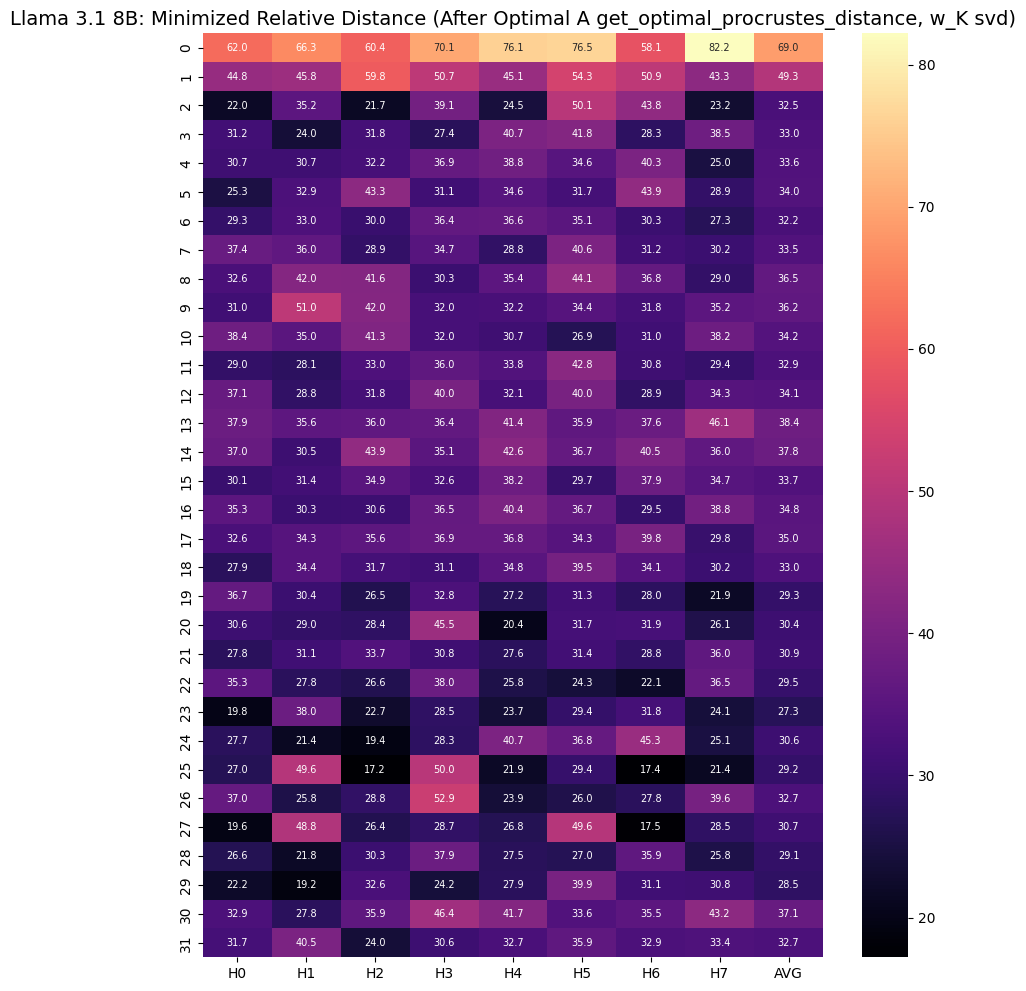

Global Average Distance after alignment: 34.43%


In [49]:
calculate_dist_with_optimal_A()

Calculating Optimized Procrustes Distances...


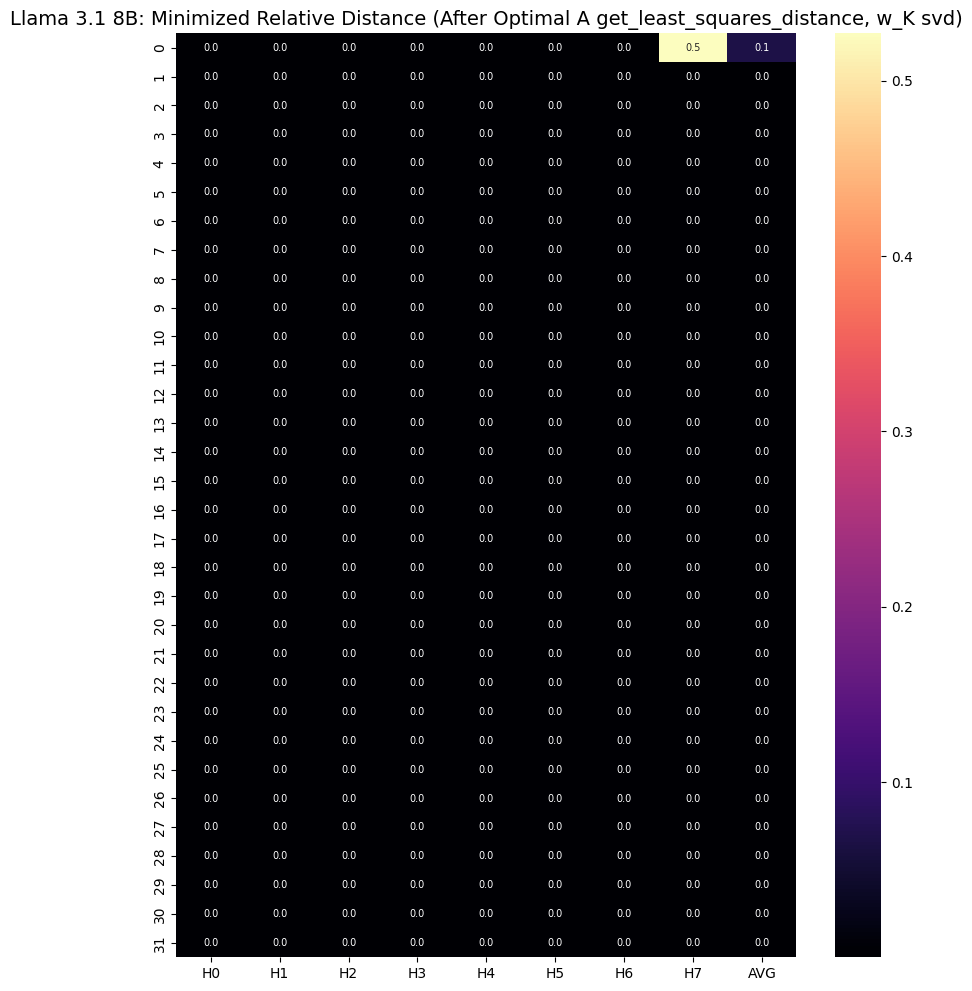

Global Average Distance after alignment: 0.00%


In [50]:
calculate_dist_with_optimal_A(opt_mat_func=get_least_squares_distance)

Calculating Optimized Procrustes Distances...


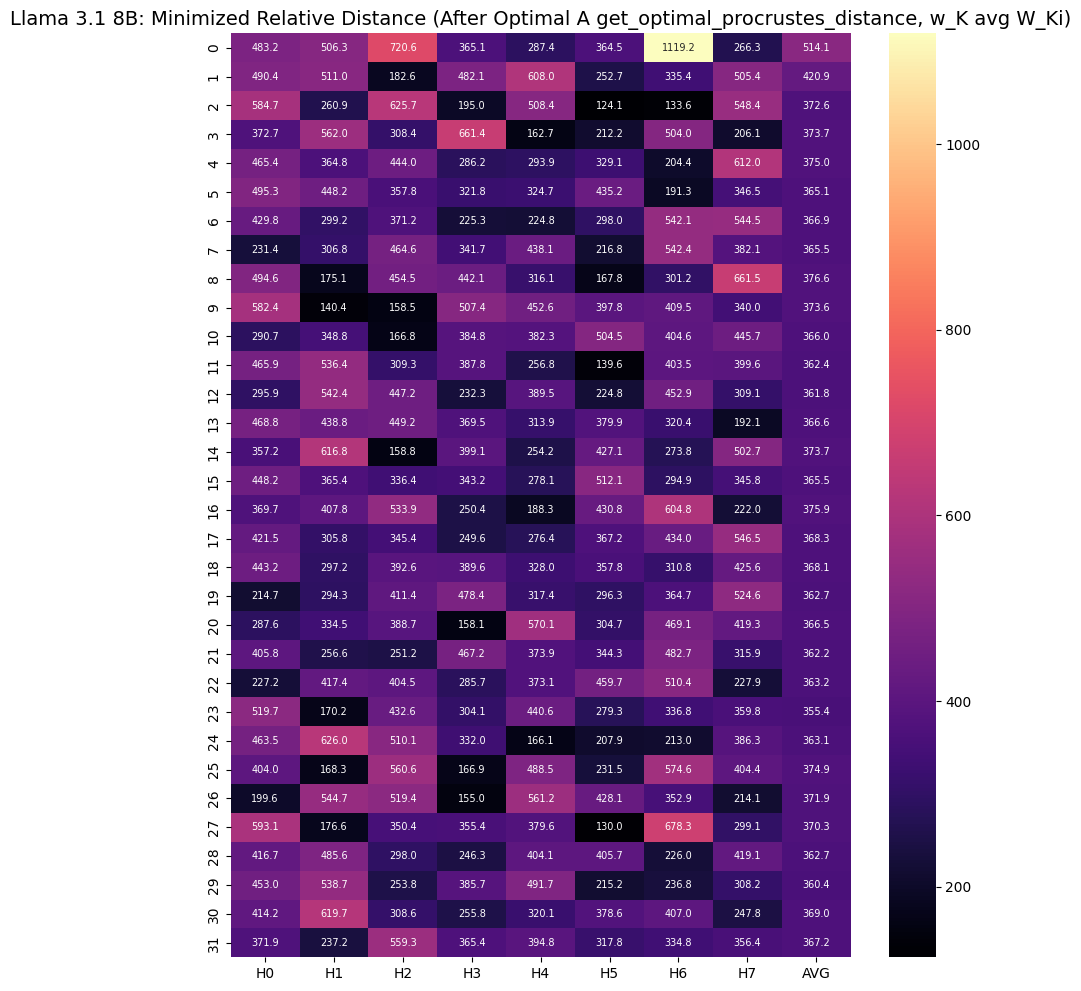

Global Average Distance after alignment: 373.80%


In [53]:
calculate_dist_with_optimal_A(w_k_name="avg W_Ki", opt_mat_func=get_optimal_procrustes_distance)

Calculating Optimized Procrustes Distances...


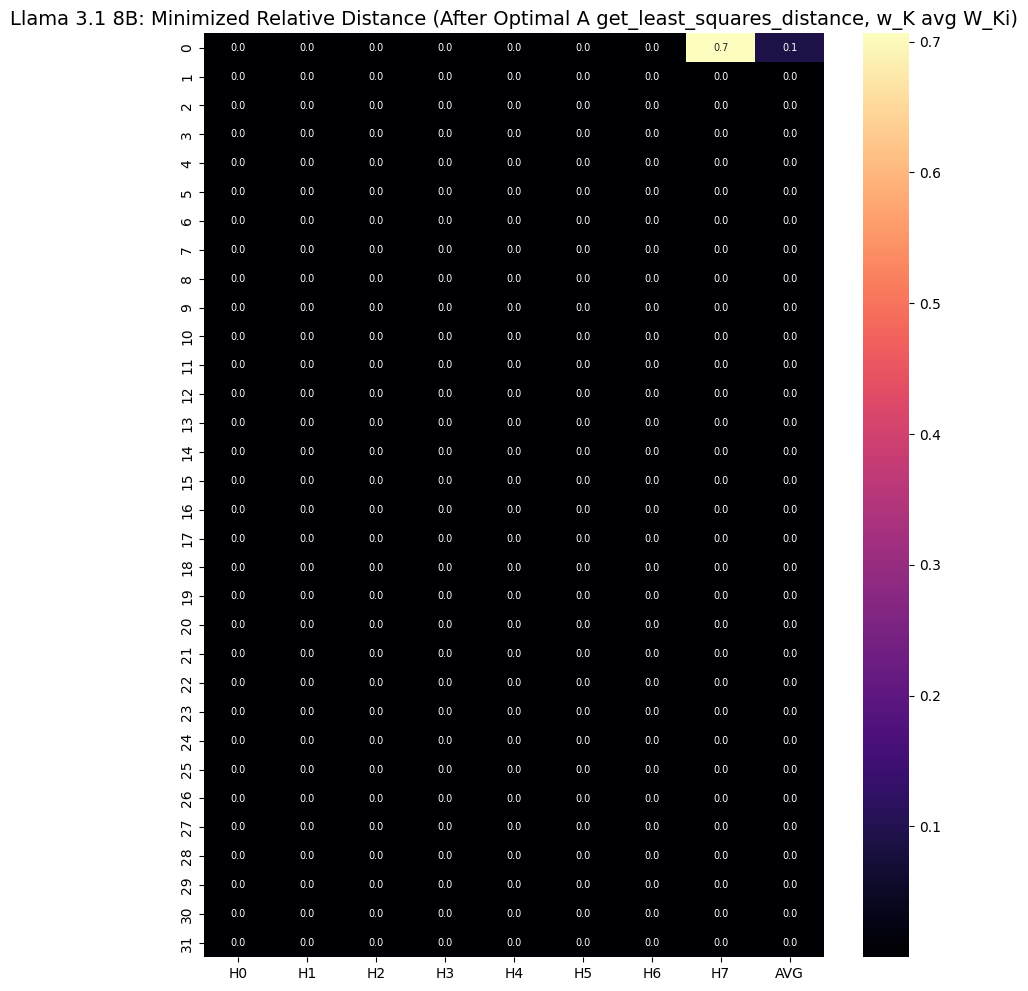

Global Average Distance after alignment: 0.00%


In [54]:
calculate_dist_with_optimal_A(w_k_name="avg W_Ki", opt_mat_func=get_least_squares_distance)

Calculating Optimized Procrustes Distances...


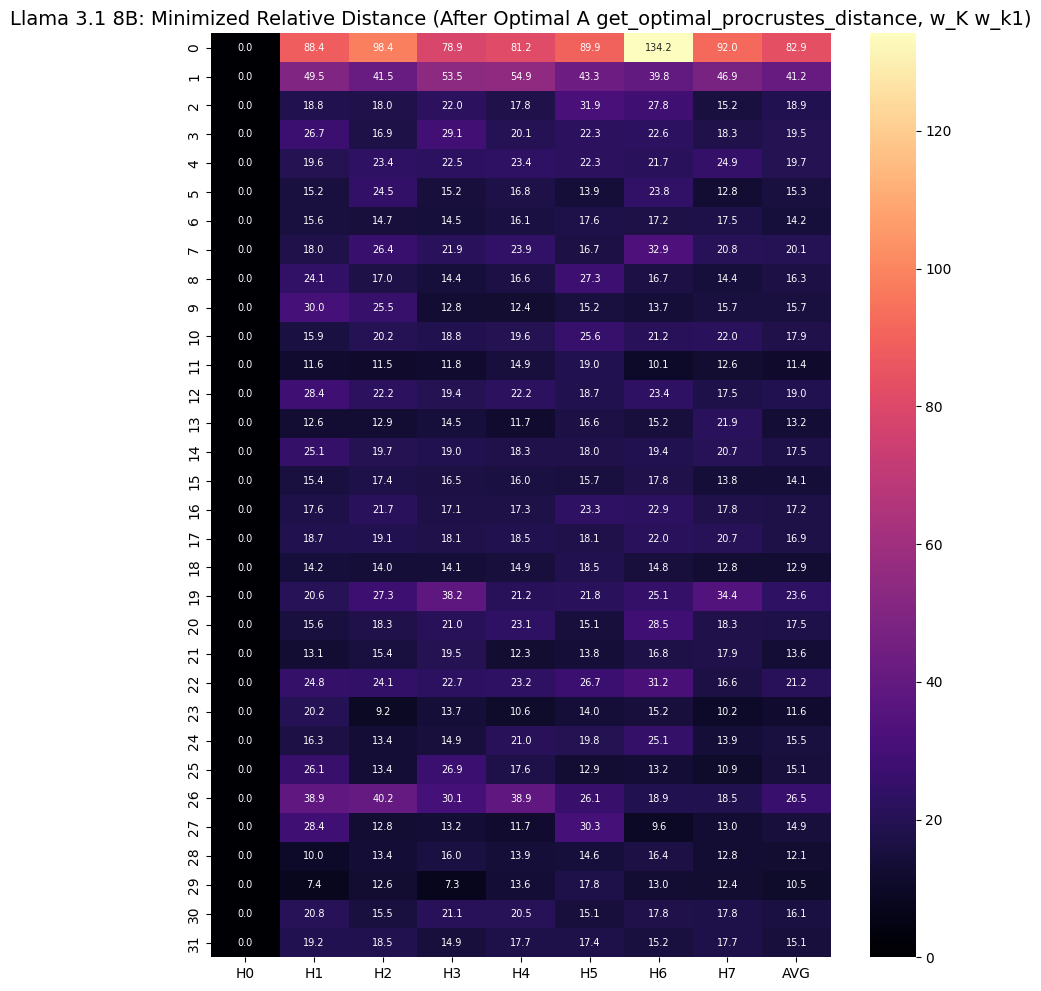

Global Average Distance after alignment: 19.29%


In [55]:
calculate_dist_with_optimal_A(w_k_name="w_k1", opt_mat_func=get_optimal_procrustes_distance)

Calculating Optimized Procrustes Distances...


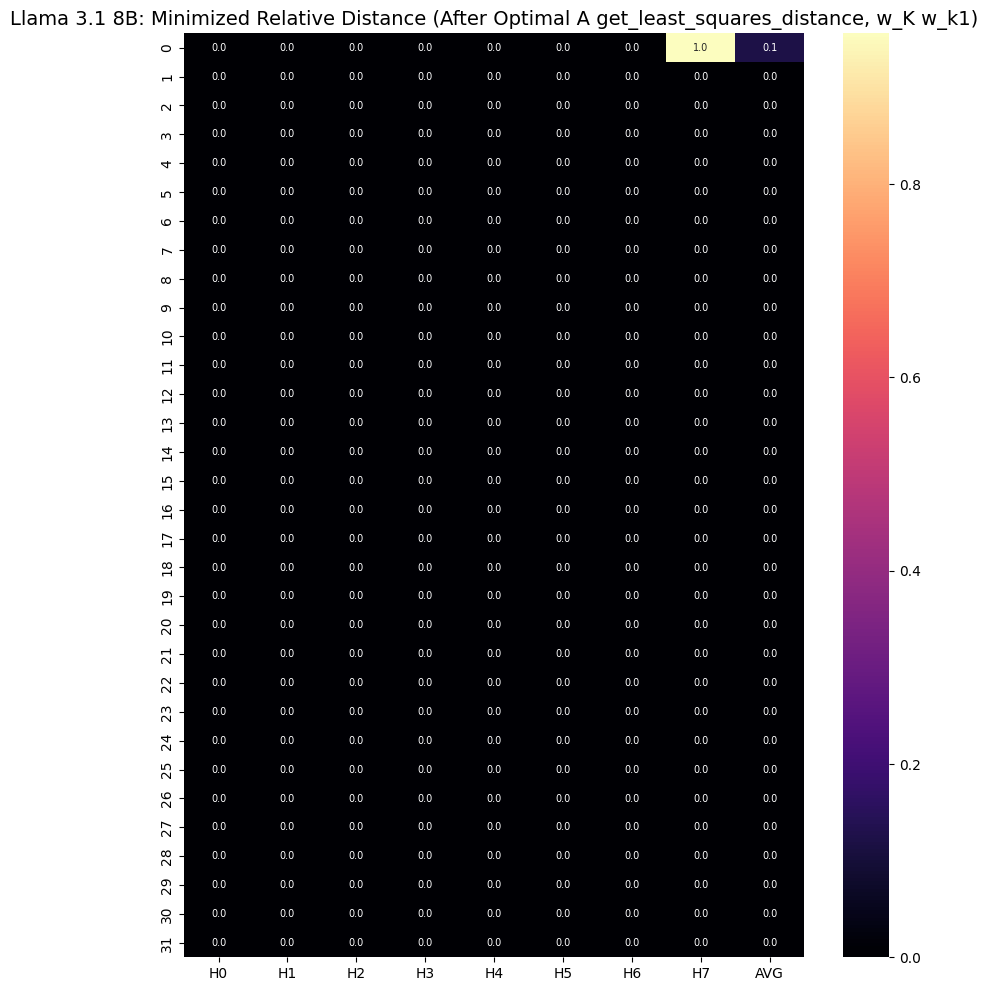

Global Average Distance after alignment: 0.00%


In [56]:
calculate_dist_with_optimal_A(w_k_name="w_k1", opt_mat_func=get_least_squares_distance)

now with A of dim 128X128 instead of 4096X4096

In [73]:
def get_least_squares_distance_v2(W_ki_raw, W_ref_raw):
    # Step 1: Transpose to work with [4096, 128]
    # Now each column is a dimension in the head space
    W_ki = W_ki_raw.t()  # [4096, 128]
    W_ref = W_ref_raw.t() # [4096, 128]
    
    # Step 2: Solve for A [128, 128] such that: W_ki @ A ≈ W_ref
    # This is a classic Least Squares problem
    # A = (W_ki^T @ W_ki)^-1 @ W_ki^T @ W_ref
    W_ki_pinv = torch.linalg.pinv(W_ki)
    A_opt = W_ki_pinv @ W_ref # [128, 128]

    rank = torch.linalg.matrix_rank(A_opt)
    print(f"Rank of A_opt: {rank.item()} (Max possible: 128)")
    
    # Step 3: Reconstruction and Distance
    W_ref_approx = W_ki @ A_opt
    
    dist_sq = torch.norm(W_ref_approx - W_ref, p='fro')**2
    ref_norm_sq = torch.norm(W_ref, p='fro')**2
    
    return (dist_sq / ref_norm_sq).item() * 100#, A_opt

# Usage in your loop:
# dist, A = get_least_squares_distance_v2(heads[h_idx], w_k_ref)

Calculating Optimized Procrustes Distances...


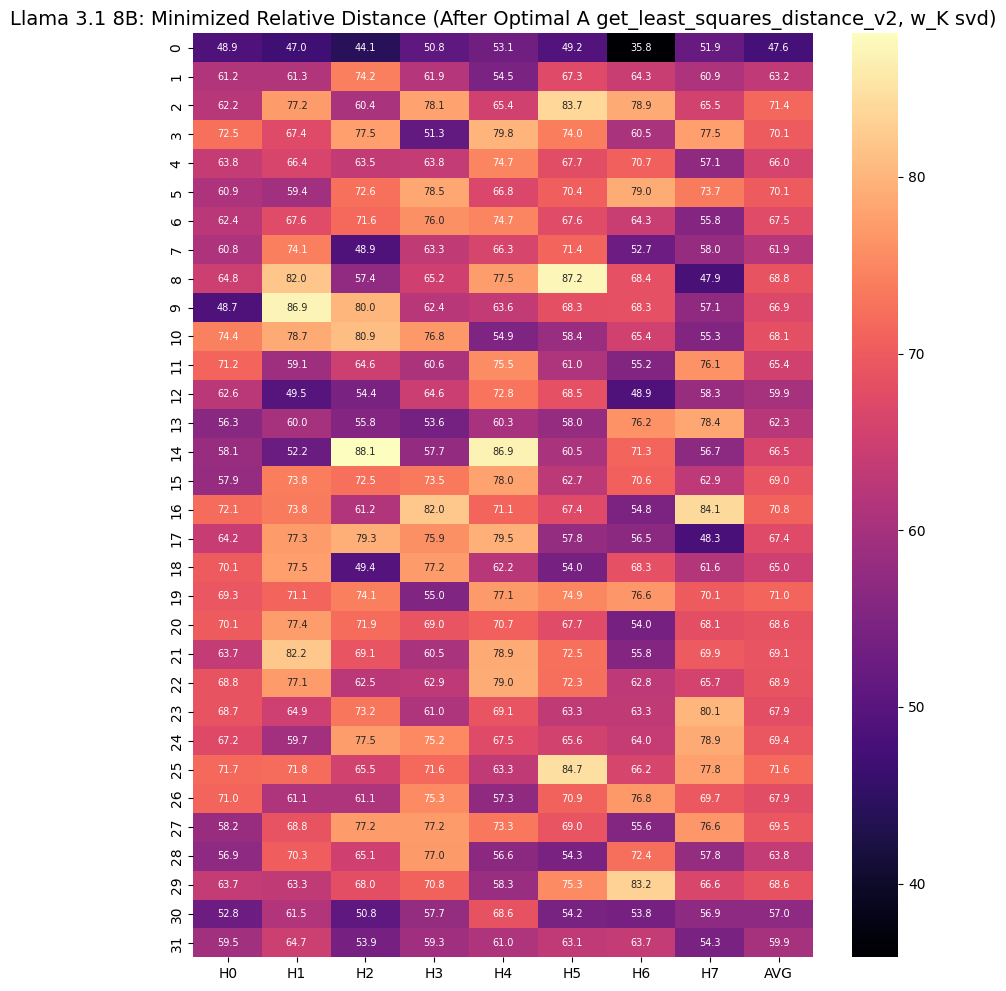

Global Average Distance after alignment: 66.29%


In [60]:
calculate_dist_with_optimal_A(w_k_name="svd", opt_mat_func=get_least_squares_distance_v2)

Calculating Optimized Procrustes Distances...


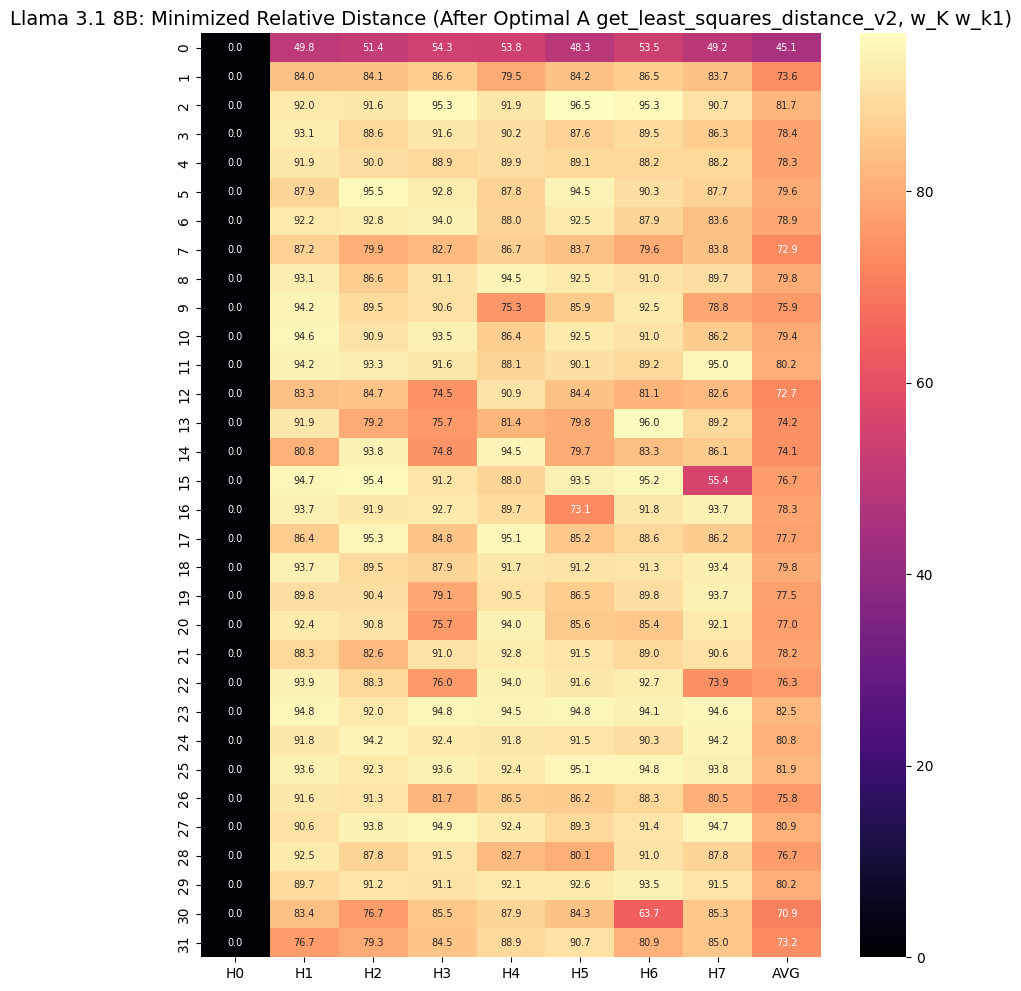

Global Average Distance after alignment: 76.53%


In [61]:
calculate_dist_with_optimal_A(w_k_name="w_k1", opt_mat_func=get_least_squares_distance_v2)

Calculating Optimized Procrustes Distances...


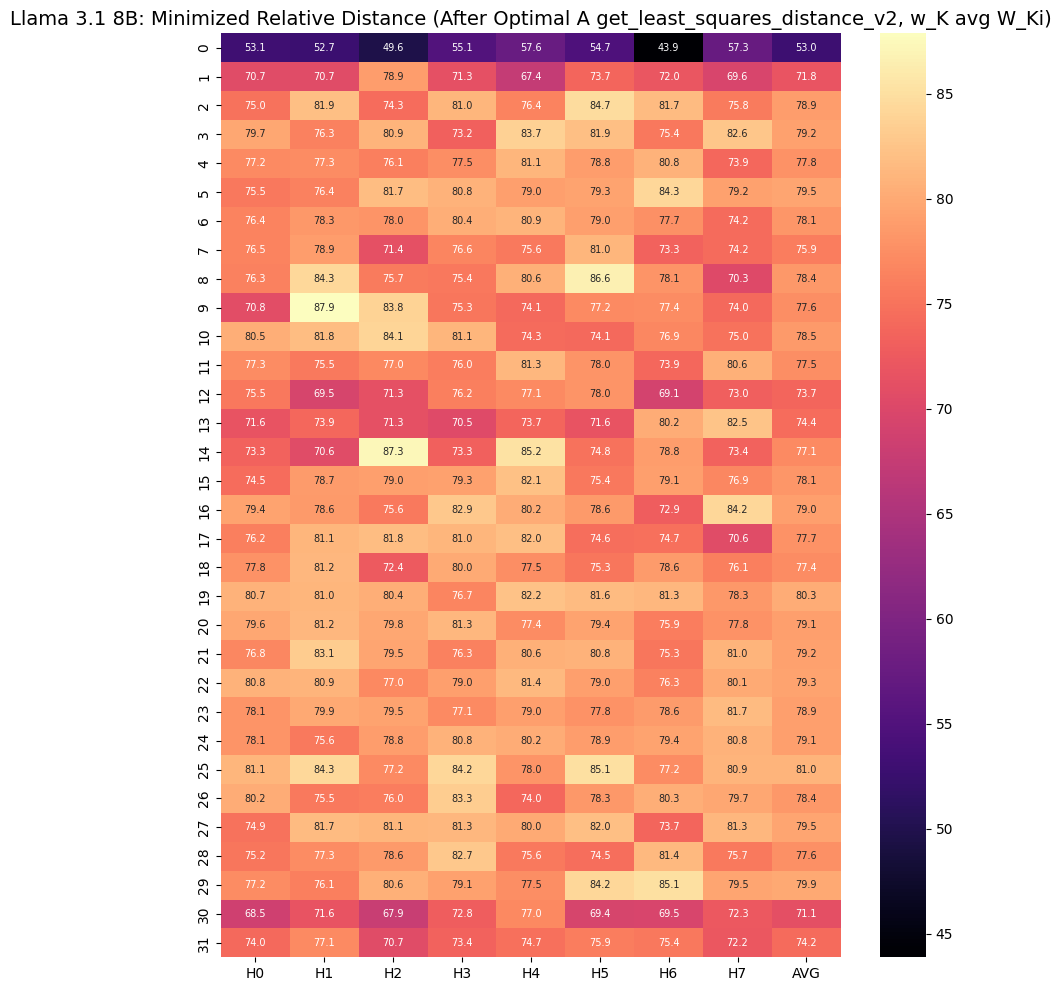

Global Average Distance after alignment: 76.91%


In [62]:
calculate_dist_with_optimal_A(w_k_name="avg W_Ki", opt_mat_func=get_least_squares_distance_v2)

In [63]:
def get_least_squares_distance_v2_unnormalized(W_ki_raw, W_ref_raw):
    # Step 1: Transpose to work with [4096, 128]
    # Now each column is a dimension in the head space
    W_ki = W_ki_raw.t()  # [4096, 128]
    W_ref = W_ref_raw.t() # [4096, 128]
    
    # Step 2: Solve for A [128, 128] such that: W_ki @ A ≈ W_ref
    # This is a classic Least Squares problem
    # A = (W_ki^T @ W_ki)^-1 @ W_ki^T @ W_ref
    W_ki_pinv = torch.linalg.pinv(W_ki)
    A_opt = W_ki_pinv @ W_ref # [128, 128]
    
    # Step 3: Reconstruction and Distance
    W_ref_approx = W_ki @ A_opt
    
    dist_sq = torch.norm(W_ref_approx - W_ref, p='fro')**2
    #ref_norm_sq = torch.norm(W_ref, p='fro')**2
    
    return (dist_sq).item()#, A_opt

# Usage in your loop:
# dist, A = get_least_squares_distance_v2(heads[h_idx], w_k_ref)

Calculating Optimized Procrustes Distances...


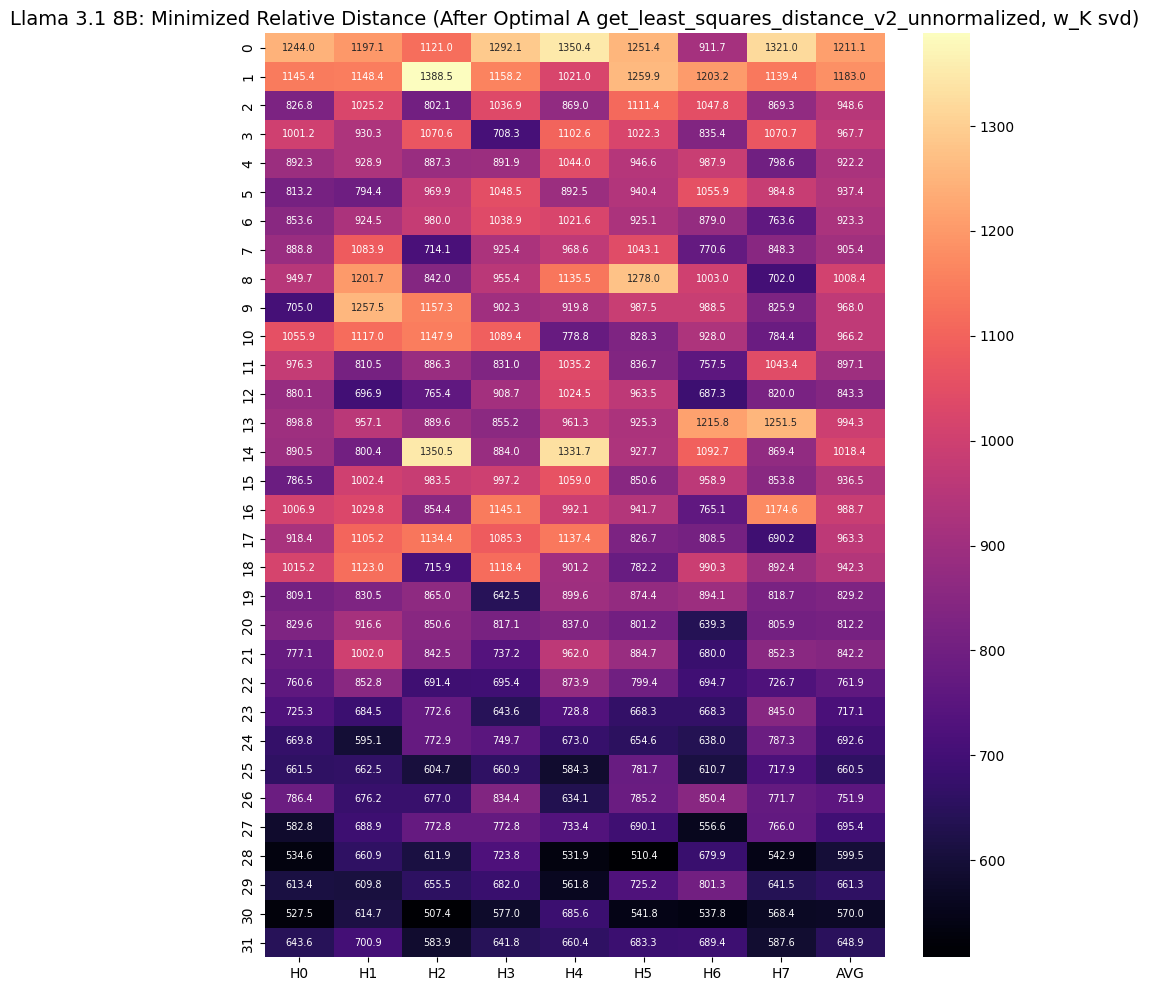

Global Average Distance after alignment: 867.74%


In [64]:
calculate_dist_with_optimal_A(w_k_name="svd", opt_mat_func=get_least_squares_distance_v2_unnormalized)

Calculating Optimized Procrustes Distances...


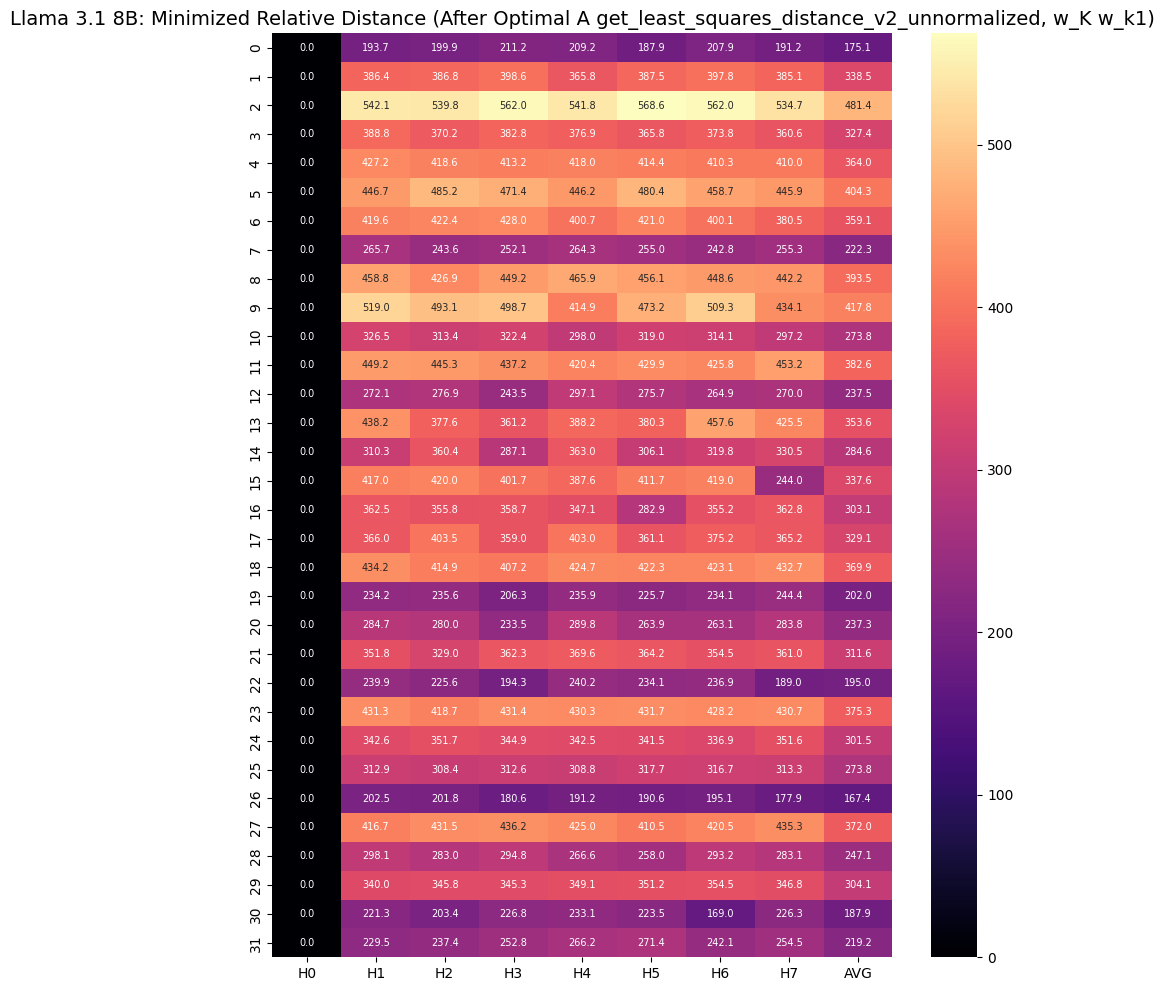

Global Average Distance after alignment: 304.67%


In [66]:
calculate_dist_with_optimal_A(w_k_name="w_k1", opt_mat_func=get_least_squares_distance_v2_unnormalized)

Calculating Optimized Procrustes Distances...


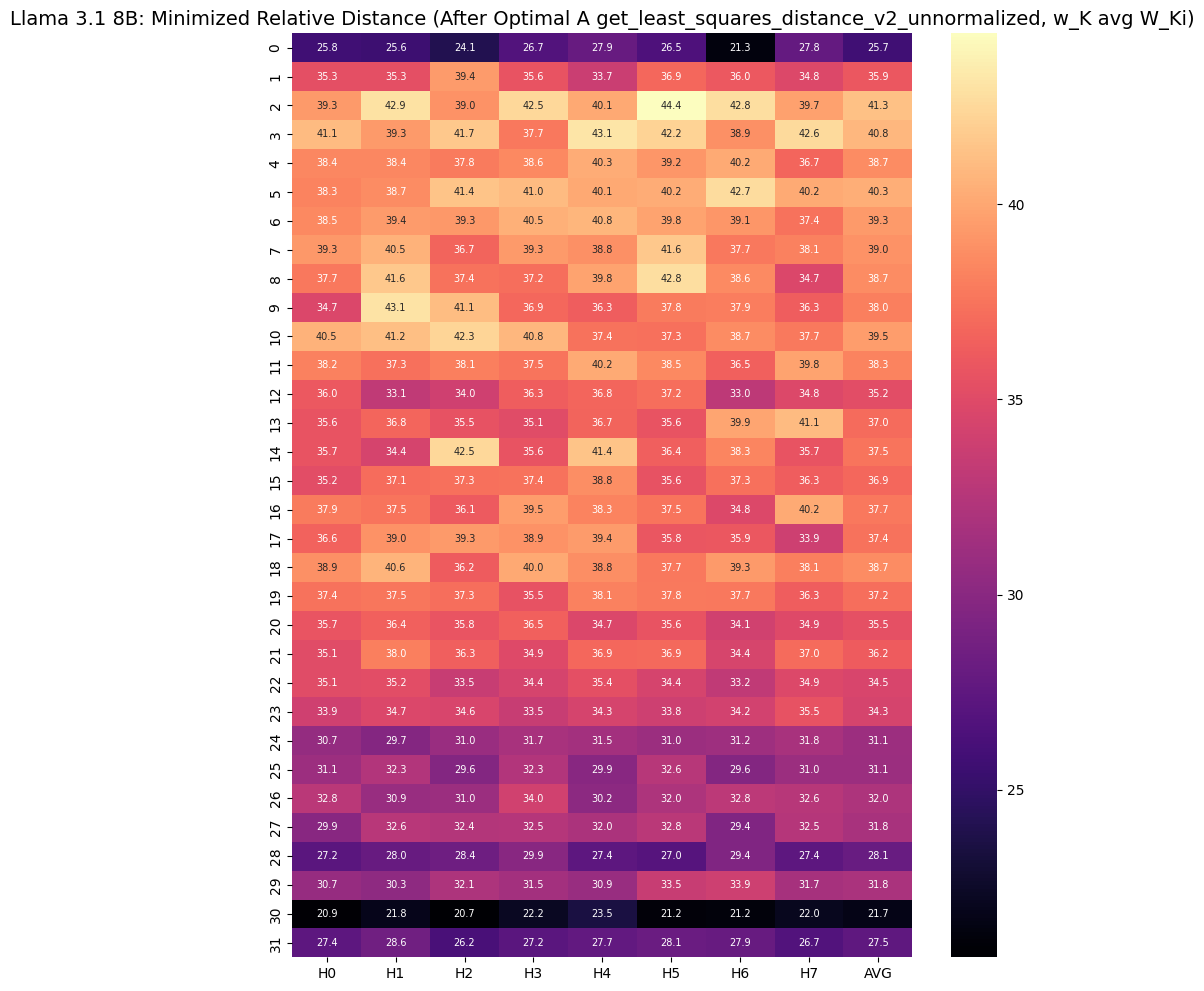

Global Average Distance after alignment: 35.27%


In [65]:
calculate_dist_with_optimal_A(w_k_name="avg W_Ki", opt_mat_func=get_least_squares_distance_v2_unnormalized)

In [72]:
calculate_dist_with_optimal_A(opt_mat_func=get_least_squares_distance)

Calculating Optimized Procrustes Distances...
Shape of W_ki: torch.Size([128, 4096])
Shape of W_ref: torch.Size([128, 4096])
Shape of W_ki_pinv: torch.Size([4096, 128])
Shape of A_opt: torch.Size([4096, 4096])
Shape of W_ki_transformed: torch.Size([128, 4096])
Shape of W_ki: torch.Size([128, 4096])
Shape of W_ref: torch.Size([128, 4096])
Shape of W_ki_pinv: torch.Size([4096, 128])
Shape of A_opt: torch.Size([4096, 4096])
Shape of W_ki_transformed: torch.Size([128, 4096])
Shape of W_ki: torch.Size([128, 4096])
Shape of W_ref: torch.Size([128, 4096])
Shape of W_ki_pinv: torch.Size([4096, 128])
Shape of A_opt: torch.Size([4096, 4096])
Shape of W_ki_transformed: torch.Size([128, 4096])
Shape of W_ki: torch.Size([128, 4096])
Shape of W_ref: torch.Size([128, 4096])
Shape of W_ki_pinv: torch.Size([4096, 128])
Shape of A_opt: torch.Size([4096, 4096])
Shape of W_ki_transformed: torch.Size([128, 4096])
Shape of W_ki: torch.Size([128, 4096])
Shape of W_ref: torch.Size([128, 4096])
Shape of W_ki_p

KeyboardInterrupt: 

Calculating Optimized Procrustes Distances...
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 127 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 127 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 127 (Max possible: 128)
Rank of A_opt: 128 (Max possible: 128)
Rank of A_opt: 128

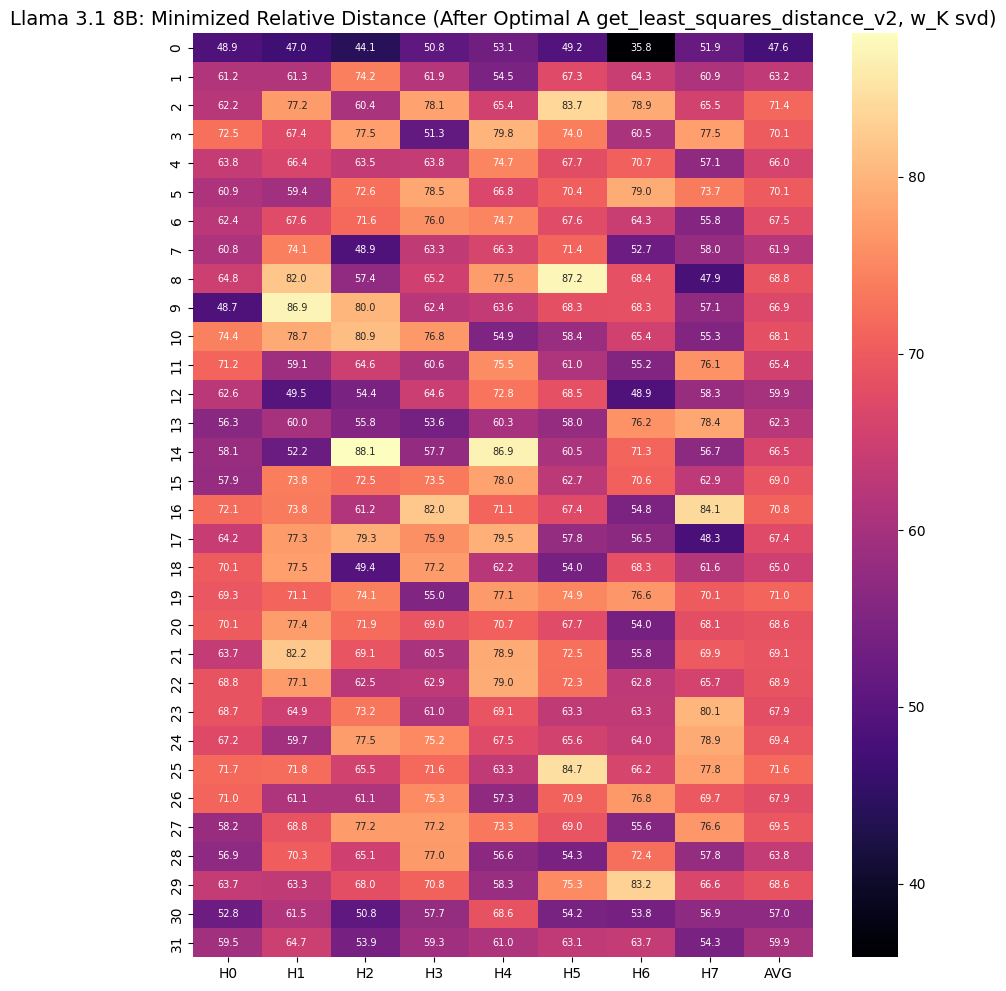

Global Average Distance after alignment: 66.29%


In [74]:
calculate_dist_with_optimal_A(w_k_name="svd", opt_mat_func=get_least_squares_distance_v2)

Calculating Optimized Procrustes Distances...


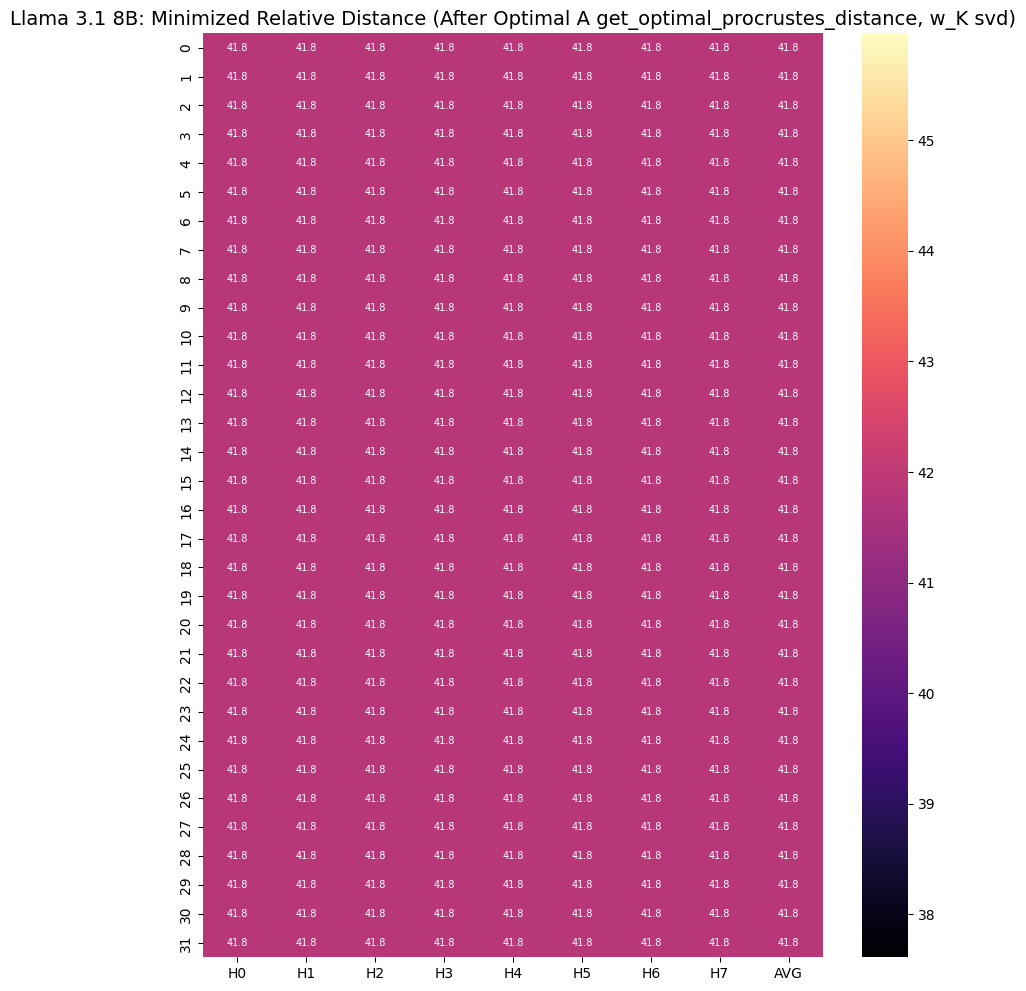

Global Average Distance after alignment: 41.79%


In [11]:
calculate_dist_with_optimal_A(w_k_name="svd", sanity_check=True)

Analyse what happens with RoPE

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import numpy as np

# Setup
model_id = "meta-llama/Meta-Llama-3.1-8B"
tokenizer = AutoTokenizer.from_pretrained(model_id)
device = "cuda" if torch.cuda.is_available() else "cpu"

# נניח שכבר חישבת את A_opt ו-W_k_ref עבור שכבה 0, ראש 1
# כאן אני מייצר placeholder - את צריכה להציב את המטריצות שלך
# A_opt: [4096, 4096] (או גודל אחר שתואם את ה-Query)
# W_k_ref: [128, 4096]

def validate_a_transformation(layer_idx, head_idx, A_opt, W_k_ref):
    activations = {}

    # פונקציית Hook לשליפת ה-Q וה-K בזמן אמת
    def hook_fn(module, input, output):
        # ב-Llama 3.1, הפלט של Attention הוא tuple (hidden_states, self_attn_weights, present_key_value)
        # אנחנו צריכים לתפוס את ה-Query וה-Key המקוריים
        # שים לב: המיקום המדויק תלוי במימוש של HF, לעיתים עדיף להשתמש ב-Hooks על q_proj ו-k_proj
        pass

    # דרך פשוטה יותר: שימוש ב-forward hooks על הפרוג'קציות
    def get_q_hook(model, input, output): activations['q'] = output
    def get_k_hook(model, input, output): activations['k'] = output

    handle_q = model.model.layers[layer_idx].self_attn.q_proj.register_forward_hook(get_q_hook)
    handle_k = model.model.layers[layer_idx].self_attn.k_proj.register_forward_hook(get_k_hook)

    # הרצה על טקסט אמיתי
    text = "The quick brown fox jumps over the lazy dog"
    inputs = tokenizer(text, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    # 2. חילוץ הנתונים עבור הראש הספציפי
    # q_raw shape: [batch, seq_len, 4096] (לכל הראשים)
    q_raw = activations['q']
    k_raw = activations['k']
    
    # חילוץ הסטייט של הראש הספציפי (לפני RoPE)
    q_head = q_raw.view(1, -1, 32, 128)[:, :, head_idx, :]
    k_head = k_raw.view(1, -1, 8, 128)[:, :, head_idx, :] # ב-Llama 3.1 יש 8 Key heads

    # 3. החישוב המקורי (Ground Truth)
    # Score = Q * K^T
    original_scores = torch.matmul(q_head, k_head.transpose(-1, -2))

    # 4. החישוב עם התיקון שלך (The Trick)
    # אנחנו מחליפים את K המקורי ב-W_k_ref, ומתקנים את Q בעזרת A
    # קודם נחשב את ה-K ה"חדש" (זה שיהיה ב-Cache)
    k_ref_simulated = inputs.input_ids.float() @ W_k_ref.T # פישוט של האקטיבציה
    
    # נתקן את ה-Query
    q_corrected = q_head @ A_opt # הנחה ש-A פועלת על מרחב הראש
    
    # חישוב ה-Score המקורב
    approx_scores = torch.matmul(q_corrected, k_ref_simulated.transpose(-1, -2))

    # 5. השוואת התוצאות
    diff = torch.norm(original_scores - approx_scores) / torch.norm(original_scores)
    
    print(f"--- Results for Layer {layer_idx}, Head {head_idx} ---")
    print(f"Attention Score Divergence: {diff.item():.4%}")
    
    if diff < 0.05:
        print("Success! The transformation is stable for inference.")
    else:
        print("Warning: High divergence. RoPE or non-linearities might be interfering.")

    handle_q.remove()
    handle_k.remove()

# הרצה
# validate_a_transformation(0, 1, A_your_matrix, W_k_ref_your_matrix)